## **Start**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import protocol_impure as im
from strawberryfields.ops import *
from importlib import reload
def reload_protocols():
    reload(im)

## Displaced Squeezed Thermal States (**DSTS**) - ***Produce*** data

In [119]:
mus_grid = np.linspace(0, 1, 101)
beta_grid = np.concatenate([
    np.linspace(0, 0.01, 301, endpoint=False),
    np.linspace(0.01, 1.0, 101)])
    
sigmas = np.linspace(0, 1, 101)

In [96]:
reload_protocols()

N = 4

num_samples = int(1e9)

for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dsts = im.perr_dsts(N, mus_grid, beta_grid, sigma, num_samples)
    
    #save data
    np.savez(f"data/DSTS/perr_dsts_N{N}_b{len(beta_grid)}_mu{len(mus_grid)}_S{num_samples}_sigma{sigma}.npz", N=N, beta_grid = beta_grid, mus_grid = mus_grid, perr=perr_dsts, sigma = sigma)



 σ = 0.0
Progress: 101/101
 σ = 0.01
Progress: 101/101
 σ = 0.02
Progress: 101/101
 σ = 0.03
Progress: 101/101
 σ = 0.04
Progress: 101/101
 σ = 0.05
Progress: 101/101
 σ = 0.06
Progress: 101/101
 σ = 0.07
Progress: 101/101
 σ = 0.08
Progress: 101/101
 σ = 0.09
Progress: 101/101
 σ = 0.1
Progress: 101/101
 σ = 0.11
Progress: 101/101
 σ = 0.12
Progress: 101/101
 σ = 0.13
Progress: 101/101
 σ = 0.14
Progress: 101/101
 σ = 0.15
Progress: 101/101
 σ = 0.16
Progress: 101/101
 σ = 0.17
Progress: 101/101
 σ = 0.18
Progress: 101/101
 σ = 0.19
Progress: 101/101
 σ = 0.2
Progress: 101/101
 σ = 0.21
Progress: 101/101
 σ = 0.22
Progress: 101/101
 σ = 0.23
Progress: 101/101
 σ = 0.24
Progress: 101/101
 σ = 0.25
Progress: 101/101
 σ = 0.26
Progress: 101/101
 σ = 0.27
Progress: 101/101
 σ = 0.28
Progress: 101/101
 σ = 0.29
Progress: 101/101
 σ = 0.3
Progress: 101/101
 σ = 0.31
Progress: 101/101
 σ = 0.32
Progress: 101/101
 σ = 0.33
Progress: 101/101
 σ = 0.34
Progress: 101/101
 σ = 0.3500000000000000

## Displaced Thermal States (**DTS**) - ***Produce*** data

In [97]:
reload_protocols()

N = 4

num_samples = int(1e9)

for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dts = im.perr_dts(N, mus_grid, sigma, num_samples)
    #save data
    np.savez(f"data/DTS/perr_dts_N{N}_mu{len(mus_grid)}_S{num_samples}_sigma{sigma}.npz", N=N, mus_grid = mus_grid, perr=perr_dts, sigma = sigma)



 σ = 0.0
Progress: 101/101
 σ = 0.01
Progress: 101/101
 σ = 0.02
Progress: 101/101
 σ = 0.03
Progress: 101/101
 σ = 0.04
Progress: 101/101
 σ = 0.05
Progress: 101/101
 σ = 0.06
Progress: 101/101
 σ = 0.07
Progress: 101/101
 σ = 0.08
Progress: 101/101
 σ = 0.09
Progress: 101/101
 σ = 0.1
Progress: 101/101
 σ = 0.11
Progress: 101/101
 σ = 0.12
Progress: 101/101
 σ = 0.13
Progress: 101/101
 σ = 0.14
Progress: 101/101
 σ = 0.15
Progress: 101/101
 σ = 0.16
Progress: 101/101
 σ = 0.17
Progress: 101/101
 σ = 0.18
Progress: 101/101
 σ = 0.19
Progress: 101/101
 σ = 0.2
Progress: 101/101
 σ = 0.21
Progress: 101/101
 σ = 0.22
Progress: 101/101
 σ = 0.23
Progress: 101/101
 σ = 0.24
Progress: 101/101
 σ = 0.25
Progress: 101/101
 σ = 0.26
Progress: 101/101
 σ = 0.27
Progress: 101/101
 σ = 0.28
Progress: 101/101
 σ = 0.29
Progress: 101/101
 σ = 0.3
Progress: 101/101
 σ = 0.31
Progress: 101/101
 σ = 0.32
Progress: 101/101
 σ = 0.33
Progress: 101/101
 σ = 0.34
Progress: 101/101
 σ = 0.3500000000000000

## **Plots** - Homodyne Error Probability

In [4]:
colors_1 = ["#e56ee5",  "#2ca02c",  "#ff7f0e",  "#9467bd",  "#17becf",  "#e377c2",  "#8c564b",  "#bcbd22",  "#7f7f7f",  "#5af74b"]*3
colors_2 = ["#AD0B90",  "#084108",  "#773b05",  "#460880",  "#0c6f7c",  "#5c0642",  "#941c04",  "#8b8b06",  "#212121",  "#092a06",  "#092a06"]*3

In [118]:
reload_protocols()
sigmas = [0.2, 0.5]
im.plot_homodyne_perr(sigmas, colors_1, colors_2, dsts = 'all', dts = 'all')

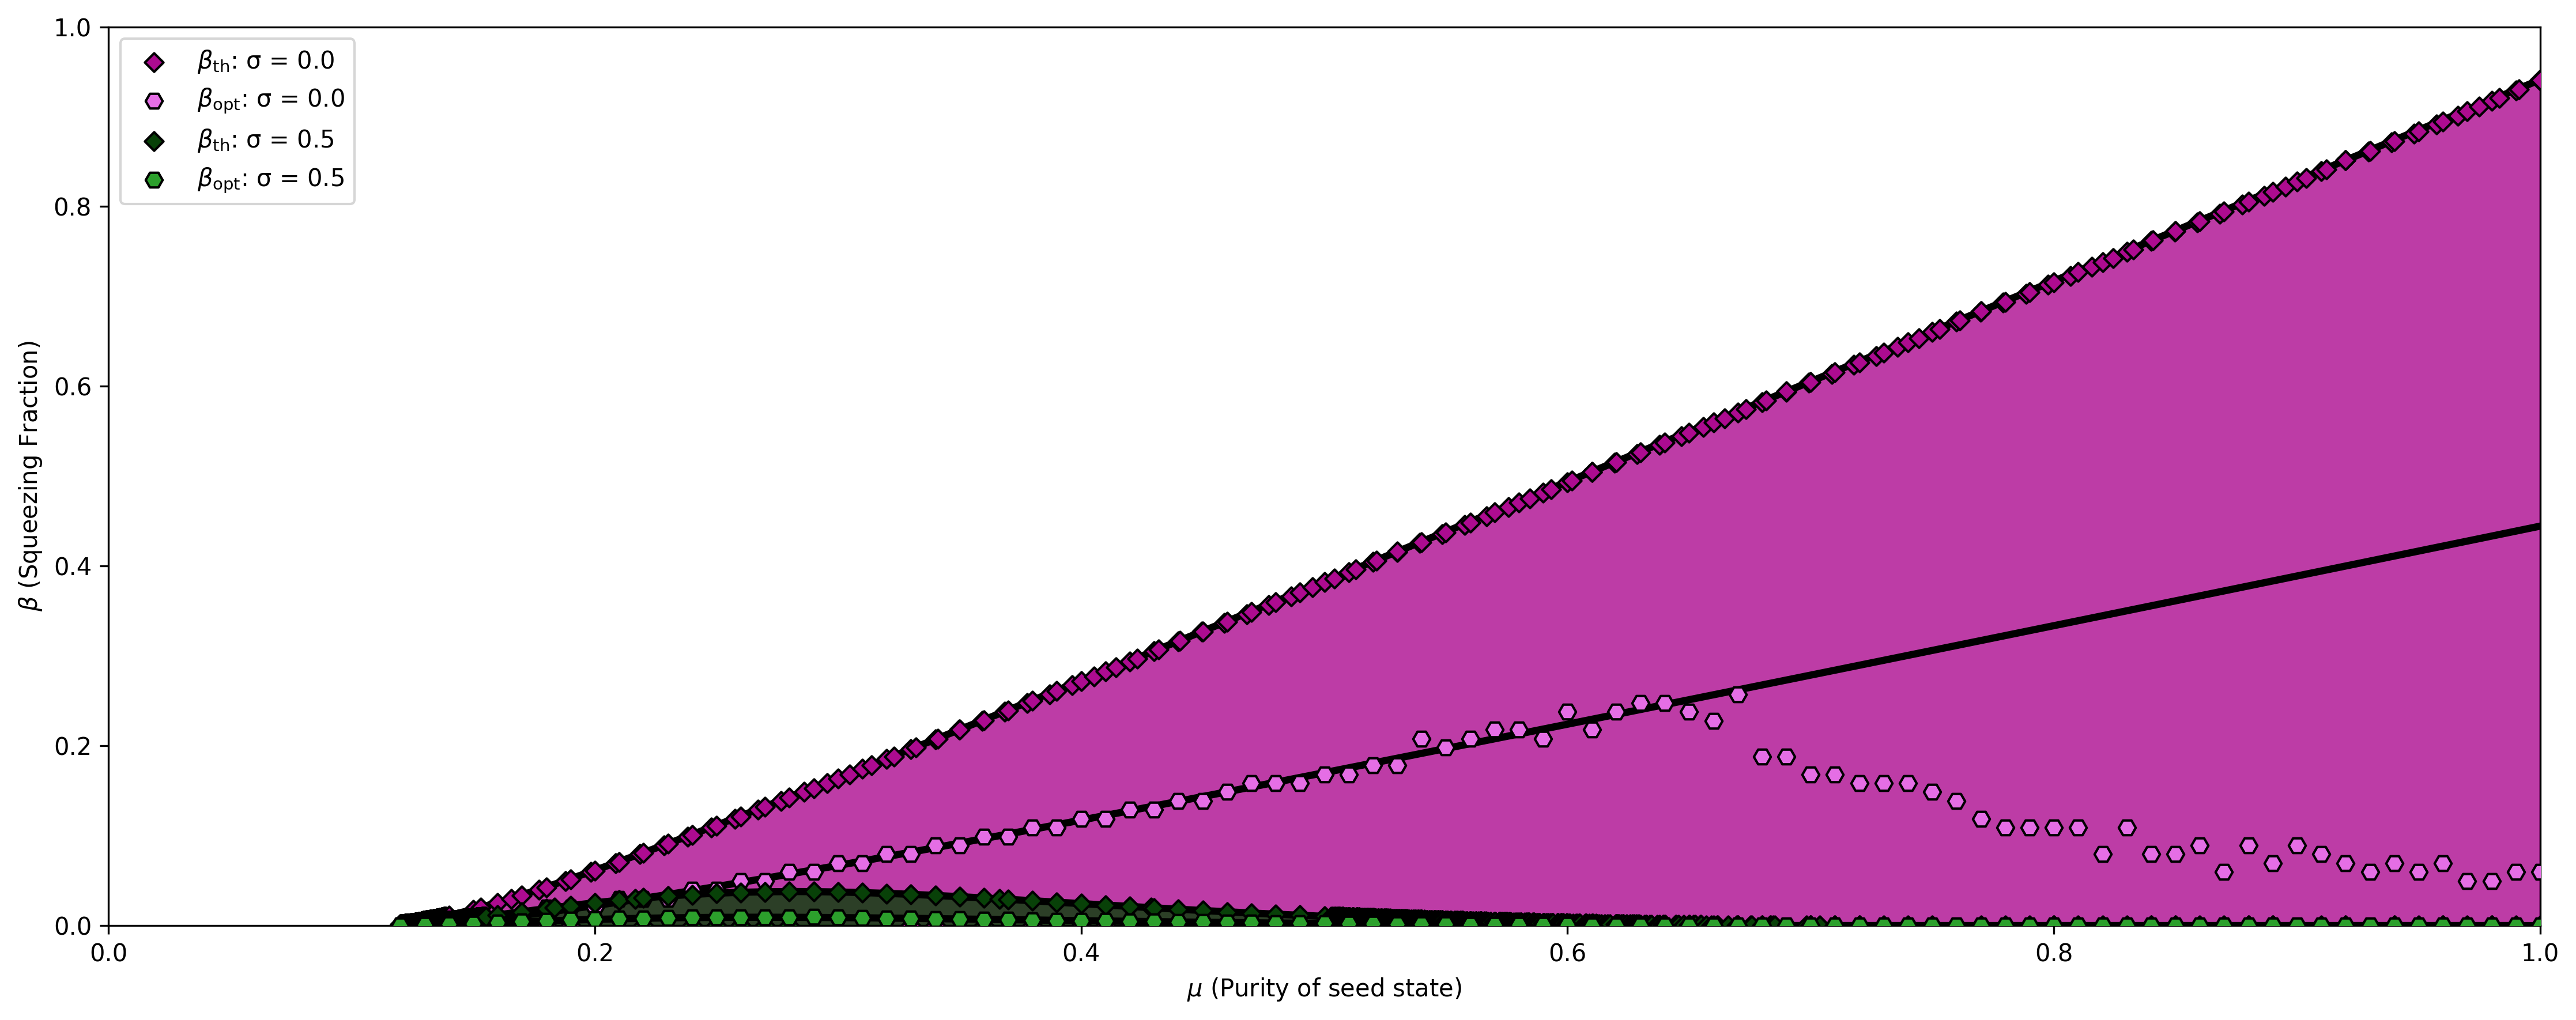

In [114]:
sigmas = [0.0, 0.5]
beta_opt = im.optimal_squeezing(sigmas, colors_1, colors_2, opt = True, th = True)

## **Plots** - Beta threshold / optimal 

In [120]:
reload_protocols()
N = 4
beta_opt = im.beta_threshold_finder(sigmas)
sigma_data = im.sigma_threshold(N, beta_opt, mus_grid)

<Figure size 640x480 with 0 Axes>

In [121]:
reload_protocols()
N_vals = [4]
colors = ['orange', 'magenta', 'cyan', 'blue']

sigma_thresholds = np.zeros((len(N_vals), len(mus_grid)))

for i, N in enumerate(N_vals):
    sigma_thresholds[i] = im.sigma_threshold_theory(N, mus_grid)

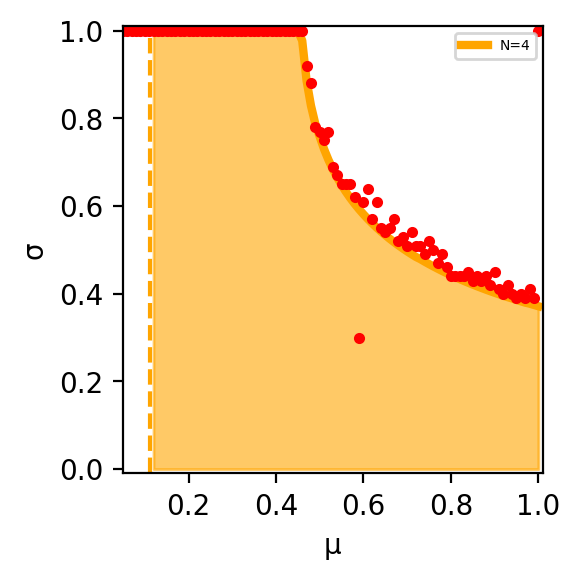

In [122]:
plt.figure(figsize=(3, 3), dpi=200)

for i, N in enumerate(N_vals):
    plt.plot(mus_grid, sigma_thresholds[i], color=colors[i], linewidth=3, label=f'N={N}')
    plt.fill_between(mus_grid, sigma_thresholds[i], 0, color=colors[i], alpha=0.6)
    plt.axvline(x=1/(1+2*N), linestyle='--', color=colors[i])

plt.ylim(-0.01, 1.01)
plt.xlim(0.05, 1.01)
plt.plot(mus_grid, sigma_data, 'r.')
plt.xlabel('μ')
plt.ylabel('σ')
plt.legend(fontsize=5)
plt.tight_layout()
plt.show()


In [59]:
sigma=0.775
print(sigma)
for i,mu in enumerate(mus_grid):
    print(f'{mus_grid[i]}:{beta_opt[f'sigma_{sigma}'][i]}')
print()
print(beta_opt[f'sigma_{sigma}'])

0.775
0.0:nan
0.01:nan
0.02:nan
0.03:nan
0.04:nan
0.05:nan
0.06:nan
0.07:nan
0.08:nan
0.09:nan
0.1:nan
0.11:nan
0.12:nan
0.13:nan
0.14:nan
0.15:nan
0.16:nan
0.17:nan
0.18:nan
0.19:nan
0.2:0.0
0.21:0.0
0.22:0.0
0.23:0.0
0.24:0.0033333333333333335
0.25:0.0033333333333333335
0.26:0.0033333333333333335
0.27:0.0033333333333333335
0.28:0.0033333333333333335
0.29:0.0033333333333333335
0.3:0.0033333333333333335
0.31:0.006666666666666667
0.32:0.006666666666666667
0.33:0.006666666666666667
0.34:0.006666666666666667
0.35000000000000003:0.006666666666666667
0.36:0.006666666666666667
0.37:0.006666666666666667
0.38:0.006666666666666667
0.39:0.006666666666666667
0.4:0.006666666666666667
0.41000000000000003:0.006666666666666667
0.42:0.006666666666666667
0.43:0.006666666666666667
0.44:0.006666666666666667
0.45:0.006666666666666667
0.46:0.006666666666666667
0.47000000000000003:0.006666666666666667
0.48:0.006666666666666667
0.49:0.006666666666666667
0.5:0.006666666666666667
0.51:0.006666666666666667
0.52